# **Microproyecto 3 — Fine-Tuning de Llama-3.2-1B con LoRA para QA**

Equipo: 2

## **Estudiantes**
- Juan Sebastián Casas Castillo
- Juan Camilo Martinez Velez
- Javier Andres Marin Gallon
- Isabella Del Pilar Camargo Salazar
- Leandro Jiménez Puerta

---

## **Contenido**
- [0. Configuración](#sec0)
  - [0.1 Entorno (Colab / local)](#sec01)
  - [0.2 Imports y variables globales](#sec02)
- [1. Datos — RACE](#sec1)
  - [1.1 Carga y *f*iltrado](#sec11)
  - [1.2 Train / Val / Test split](#sec12)
  - [1.3 Vista rápida](#sec13)
  - [1.4 Distribución de atributos](#sec14)
- [2. Modelo base — Llama-3.2-1B](#sec2)
  - [2.1 Carga del modelo y tokenizador](#sec21)
  - [2.2 *F*ormato del prompt de evaluación](#sec22)
  - [2.3 *F*unción de log-probabilidad](#sec23)
  - [2.4 Evaluación del modelo base](#sec24)
- [3. Fine-tuning con LoRA](#sec3)
  - [3.1 Configuración de LoRA (PEFT)](#sec31)
  - [3.2 Dataset de entrenamiento](#sec32)
  - [3.3 Entrenamiento](#sec33)
  - [3.4 Guardado del checkpoint](#sec34)
  - [3.5 Curvas de pérdida](#sec35)
- [4. Evaluación comparativa](#sec4)
  - [4.1 Carga del modelo *f*inetuneado](#sec41)
  - [4.2 Evaluación del modelo *f*inetuneado](#sec42)
  - [4.3 Tabla resumen](#sec43)
  - [4.4 Análisis por categoría](#sec44)
- [5. Conclusiones](#sec5)
- [6. Carga de modelos e inferencia](#sec6)
  - [6.0 Imports y configuración](#sec60)
  - [6.1 Carga del checkpoint LoRA](#sec61)
  - [6.2 Ejemplo de inferencia](#sec62)

A lo largo de este notebook se usan rutas relativas a `DRIVE_BASE` para cargar checkpoints
y artefactos del modelo. Es necesario ajustar esta variable según el entorno de ejecución
(Colab o local) en la **Sección 0.1**.

Si únicamente se desea verificar los resultados sin reentrenar el modelo, ir directamente a la
[Sección 6](#sec6) y ejecutarla de forma completa. Asegurarse de que `DRIVE_BASE` apunte al
directorio donde se guardó el checkpoint LoRA.

<a id='sec0'></a>

# 0. Configuración

<a id='sec01'></a>

## 0.1 Entorno (Colab / local)

Se define el *f*lag `COLAB` para controlar el entorno de ejecución. Si `COLAB = True`,
se monta Google Drive y se instalan las dependencias necesarias. Si `COLAB = False`,
se asume un entorno local con las dependencias ya instaladas.

El *f*lag `TRAIN` controla si se ejecuta el entrenamiento (`True`) o si se carga
directamente el checkpoint guardado (`False`).

In [37]:
# False → local  |  True → Google Colab
COLAB = True
TRAIN = True

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q --upgrade torchao
    !pip install -q peft accelerate bitsandbytes

    DRIVE_BASE    = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_3'
    # DRIVE_BASE  = ''  # COLOCAR RUTA DONDE ESTÁN LOS CHECKPOINTS

    CKPT_LORA     = f'{DRIVE_BASE}/checkpoints/llama_lora.pt'
    CKPT_LORA_DIR = f'{DRIVE_BASE}/checkpoints/llama_lora_adapter'
else:
    DRIVE_BASE    = '.'
    CKPT_LORA     = './checkpoints/llama_lora.pt'
    CKPT_LORA_DIR = './checkpoints/llama_lora_adapter'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
from huggingface_hub import login

HF_TOKEN = 'hf_TU_TOKEN_AQUI'  # ← inserta tu token de Hugging Face aquí
login(token=HF_TOKEN)


<a id='sec02'></a>

## 0.2 Imports y variables globales

Se importan todas las librerías necesarias, se *f*ija la semilla de reproducibilidad
y se definen los hiperparámetros globales del experimento.

In [39]:
import os
import warnings

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader as TorchDataLoader, Dataset as TorchDataset

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

import transformers
import datasets as _ds
transformers.logging.set_verbosity_error()
_ds.disable_progress_bar()


In [40]:
# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Modelo ────────────────────────────────────────────────────────────────────
MODEL_NAME  = 'meta-llama/Llama-3.2-1B'
MAX_ART_LEN = 800

# ── LoRA ──────────────────────────────────────────────────────────────────────
LORA_R       = 32
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                 'gate_proj', 'up_proj', 'down_proj']

# ── Entrenamiento ─────────────────────────────────────────────────────────────
BATCH_SIZE   = 8
GRAD_ACCUM   = 4        # lote efectivo = 32
LR           = 2e-4
N_EPOCHS     = 4        # early stopping para antes si val loss sube
WARMUP_RATIO = 0.06
MAX_SEQ_LEN  = 512

LABEL_IGNORE = -100

print(f'Dispositivo : {device}')
print(f'Modelo      : {MODEL_NAME}')
print(f'LoRA r / α  : {LORA_R} / {LORA_ALPHA}')
print(f'Targets     : {LORA_TARGETS}')


Dispositivo : cuda
Modelo      : meta-llama/Llama-3.2-1B
LoRA r / α  : 32 / 32
Targets     : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


<a id='sec1'></a>

# 1. Datos — RACE

El conjunto de datos **RACE** (*ReAding Comprehension dataset from Examinations*) contiene
aproximadamente 100 000 preguntas de opción múltiple extraídas de exámenes de comprensión
del inglés realizados en escuelas de China. Cada ejemplo incluye:

- **`article`**: un *f*ragmento de texto de lectura
- **`question`**: una pregunta sobre el artículo
- **`options`**: lista con cuatro opciones de respuesta (A, B, C, D)
- **`answer`**: la letra de la respuesta correcta (`'A'`, `'B'`, `'C'` o `'D'`)

Para reducir los tiempos de entrenamiento y evaluación, se aplica el *f*iltro
`len(article) < 800` caracteres tanto en el split de entrenamiento como en el de evaluación.

<a id='sec11'></a>

## 1.1 Carga y *f*iltrado

Se cargan los archivos parquet directamente desde Hugging Face con el protocolo `hf://`
y se convierten a objetos `Dataset`. Esto garantiza compatibilidad con el resto del
código (filtrado, iteración) sin depender del `load_dataset` estándar, que puede
presentar problemas con el backend XET de este dataset.

A continuación se aplica el *f*iltro `len(article) < 800` caracteres.

In [41]:
_splits_files = {
    'train'     : 'all/train-00000-of-00001.parquet',
    'validation': 'all/validation-00000-of-00001.parquet',
    'test'      : 'all/test-00000-of-00001.parquet',
}

raw = DatasetDict({
    split: Dataset.from_pandas(
        pd.read_parquet(f'hf://datasets/ehovy/race/{path}'),
        preserve_index=False,
    )
    for split, path in _splits_files.items()
})

print('Dataset cargado:')
print(raw)

def filter_fn(example):
    return len(example['article']) < MAX_ART_LEN

race_train = raw['train'].filter(filter_fn)
race_val   = raw['validation'].filter(filter_fn)
race_test  = raw['test'].filter(filter_fn)

print(f'\nDespués del filtro (len(article) < {MAX_ART_LEN}):')
print(f'Train : {len(race_train):,}')
print(f'Val   : {len(race_val):,}')
print(f'Test  : {len(race_test):,}')

Dataset cargado:
DatasetDict({
    train: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 87866
    })
    validation: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4887
    })
    test: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4934
    })
})

Después del filtro (len(article) < 800):
Train : 8,930
Val   : 514
Test  : 480


<a id='sec12'></a>

## 1.2 Train / Val / Test split

Se usan los splits nativos del dataset. El conjunto de **validación** se usa para
monitorear la pérdida durante el entrenamiento. El conjunto de **test** se reserva
exclusivamente para la evaluación *f*inal comparativa entre el modelo base y el
*f*inetuneado; no se usa durante el entrenamiento en ninguna etapa.

In [42]:
print(f'Train: {len(race_train):,} | Val: {len(race_val):,} | Test: {len(race_test):,}')


Train: 8,930 | Val: 514 | Test: 480


<a id='sec13'></a>

## 1.3 Vista rápida

Se muestra el primer ejemplo del split de entrenamiento para verificar el *f*ormato
de los datos y *f*amiliarizarse con la estructura de las preguntas RACE.

In [43]:
ex = race_train[0]
print(f'[ARTÍCULO]  {ex["article"][:300]}...')
print(f'\n[PREGUNTA]  {ex["question"]}')
print('\n[OPCIONES]')
for i, opt in enumerate(ex['options']):
    label = chr(ord('A') + i)
    print(f'  ({label}) {opt}')
print(f'\n[RESPUESTA] {ex["answer"]}')

[ARTÍCULO]  The air hostess   was in a small kitchen at the back of the plane, preparing the plates for lunch, when a little old lady came and spoke to her, "Could you please tell me," she asked, "where is the ladies' lavatory   in the plane?"
"Yes, madam," said the air hostess and smiled. "It is right at the o...

[PREGUNTA]  The story happened  _  .

[OPCIONES]
  (A) in the evening
  (B) in the afternoon
  (C) in the morning
  (D) at midnight

[RESPUESTA] C


<a id='sec14'></a>

## 1.4 Distribución de atributos

Se analiza la distribución de longitudes de los artículos y la distribución de
respuestas correctas (A/B/C/D) en el conjunto de entrenamiento. Una distribución
de respuestas muy desbalanceada podría introducir sesgos en el modelo.

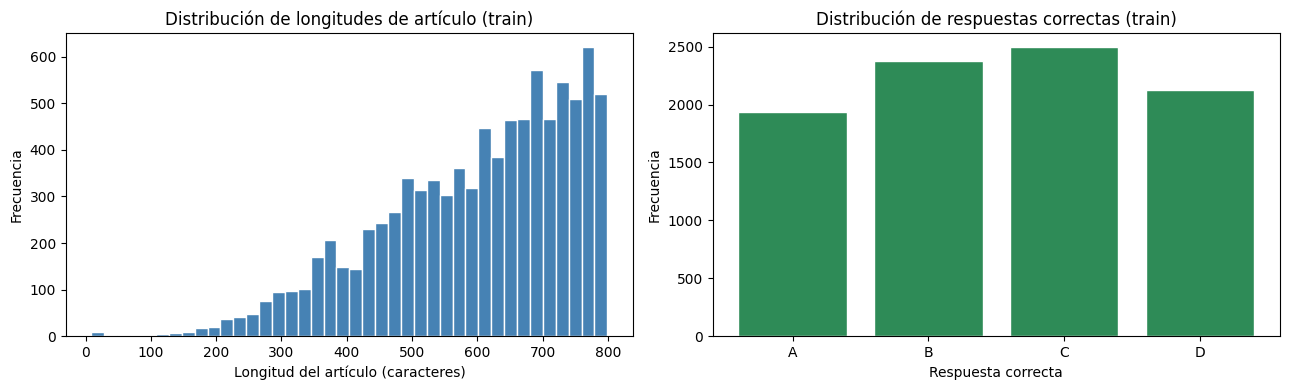

Longitud media   : 597 caracteres
Longitud mediana : 625 caracteres
Longitud máxima  : 799 caracteres

Distribución de respuestas:
A    1937
B    2373
C    2494
D    2126


In [44]:
art_lens  = [len(ex['article']) for ex in race_train]
answers   = [ex['answer']       for ex in race_train]
ans_counts = pd.Series(answers).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(art_lens, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Longitud del artículo (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitudes de artículo (train)')

axes[1].bar(ans_counts.index, ans_counts.values, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Respuesta correcta')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de respuestas correctas (train)')

plt.tight_layout()
plt.show()

print(f'Longitud media   : {np.mean(art_lens):.0f} caracteres')
print(f'Longitud mediana : {np.median(art_lens):.0f} caracteres')
print(f'Longitud máxima  : {np.max(art_lens)} caracteres')
print(f'\nDistribución de respuestas:')
print(ans_counts.to_string())

<a id='sec2'></a>

# 2. Modelo base — Llama-3.2-1B

Se carga el modelo **Llama-3.2-1B** en su versión base (sin ajuste por instrucciones)
y se evalúa su capacidad de responder preguntas de opción múltiple mediante el método
de **log-probabilidad**.

La idea central es tratar el problema de clasificación como un problema de *f*lujo
de probabilidad: para cada una de las cuatro opciones de respuesta se calcula
`log P(opción | contexto)` usando el modelo de lenguaje, y se selecciona la opción
con mayor log-probabilidad como la predicción del modelo. Este enfoque no requiere
*f*inetuning ni prompting especial; aprovecha directamente la distribución de
probabilidades que el modelo aprende durante el preentrenamiento.

<a id='sec21'></a>

## 2.1 Carga del modelo y tokenizador

Se carga el modelo en `bfloat16` para reducir el uso de memoria en GPU sin perder
precisión numérica significativa. El tokenizador de LLaMA 3 no tiene un `pad_token`
por defecto, por lo que se usa el `eos_token` como sustituto.

In [45]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map='auto',
)
base_model.eval()

n_params = sum(p.numel() for p in base_model.parameters())
print(f'Parámetros totales : {n_params:,}')
print(f'Dtype              : {next(base_model.parameters()).dtype}')

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Parámetros totales : 1,235,814,400
Dtype              : torch.bfloat16


<a id='sec22'></a>

## 2.2 *F*ormato del prompt de evaluación

Para evaluar cada opción de respuesta se construye un prompt que concatena el artículo,
la pregunta y el texto de la opción. La log-probabilidad se calcula **solo sobre los
tokens de la opción**; los tokens del contexto (artículo + pregunta + `"Answer: "`) se
usan únicamente como condicionante.

El *f*ormato exacto del prompt es:

```
Article: {article}

Question: {question}

Answer: {option_text}
```

La cadena `"Article: {article}\n\nQuestion: {question}\n\nAnswer:"` constituye el
**contexto**. El texto `{option_text}` es la **opción** cuyos tokens sí se incluyen
en el cálculo de la log-probabilidad.

Esta separación se implementa tokenizando el contexto por separado para obtener
`n_ctx = len(context_ids)`, y luego sumando los log-probs únicamente a partir de
esa posición en la secuencia completa. La suma se normaliza por el número de tokens
de la opción para evitar que opciones más largas reciban puntuaciones sistemáticamente
más bajas.

<a id='sec23'></a>

## 2.3 *F*unción de log-probabilidad

Se implementan tres *f*unciones:

1. **`build_context`**: construye la cadena de contexto a partir del artículo y la pregunta.
2. **`score_option`**: calcula la log-probabilidad promedio de una opción dado el contexto.
   La aritmética de índices es la siguiente: `logits[0, i, :]` predice el token en
   posición `i+1`, por lo que los logits predictores de los `n_option` tokens de la
   opción son `logits[0, n_ctx-1 : n_full-1, :]`.
3. **`evaluate_dataset`**: evalúa el modelo completo sobre un dataset y devuelve
   el accuracy junto con las predicciones y etiquetas verdaderas.

In [46]:
def build_context(article: str, question: str) -> str:
    return f'Article: {article}\n\nQuestion: {question}\n\nAnswer:'


def score_option(model, tokenizer, context: str, option: str) -> float:
    full_text = context + ' ' + option
    ctx_ids   = tokenizer.encode(context,   add_special_tokens=True)
    full_ids  = tokenizer.encode(full_text, add_special_tokens=True)
    n_ctx, n_full = len(ctx_ids), len(full_ids)
    n_option = n_full - n_ctx
    if n_option <= 0:
        return float('-inf')
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(input_ids).logits
    option_logits = logits[0, n_ctx - 1 : n_full - 1, :]
    option_ids    = torch.tensor(full_ids[n_ctx:], dtype=torch.long).to(device)
    log_probs = F.log_softmax(option_logits, dim=-1)
    token_lp  = log_probs[range(n_option), option_ids]
    return token_lp.sum().item() / n_option


def predict_example(model, tokenizer, example: dict) -> str:
    context = build_context(example['article'], example['question'])
    scores  = [score_option(model, tokenizer, context, opt) for opt in example['options']]
    return chr(ord('A') + int(np.argmax(scores)))


def evaluate_dataset(model, tokenizer, dataset, desc='Evaluando') -> dict:
    model.eval()
    correct, predictions, labels = 0, [], []
    for example in tqdm(dataset, desc=desc):
        pred  = predict_example(model, tokenizer, example)
        label = example['answer']
        predictions.append(pred)
        labels.append(label)
        if pred == label:
            correct += 1
    return {
        'accuracy'   : correct / len(dataset),
        'predictions': predictions,
        'labels'     : labels,
    }


<a id='sec24'></a>

## 2.4 Evaluación del modelo base

Se evalúa el modelo **Llama-3.2-1B** base sobre el conjunto de **test** del dataset
RACE *f*iltrado. Esta evaluación puede tardar varios minutos dependiendo del hardware
disponible. El resultado sirve como línea de base (*baseline*) para comparar el
impacto del *f*inetuning con LoRA.

In [47]:
results_base = evaluate_dataset(base_model, tokenizer, race_test, desc='Modelo base (test)')

acc_base = results_base['accuracy']
print(f'\nAccuracy — modelo base : {acc_base:.4f}  ({acc_base * 100:.2f} %)')
print(f'Ejemplos evaluados     : {len(race_test):,}')

Modelo base (test): 100%|██████████| 480/480 [00:46<00:00, 10.22it/s]


Accuracy — modelo base : 0.5521  (55.21 %)
Ejemplos evaluados     : 480


<a id='sec3'></a>

# 3. Fine-tuning con LoRA

Se aplica **Low-Rank Adaptation** (LoRA) al modelo Llama-3.2-1B para ajustarlo sobre
el dataset RACE. LoRA inserta matrices de bajo rango en las proyecciones de atención
del transformer, reduciendo el número de parámetros entrenables de ~1 B a ~4 M.
Esto hace el entrenamiento eficiente tanto en memoria como en tiempo.

Durante el entrenamiento el modelo aprende a predecir el **texto de la respuesta correcta**
dado el artículo y la pregunta. Los tokens del **contexto** reciben `label = -100`
(ignorados automáticamente por `CrossEntropyLoss`); solo los tokens de la opción
correcta contribuyen a la pérdida.

<a id='sec31'></a>

## 3.1 Configuración de LoRA (PEFT)

Se utiliza la librería **PEFT** de Hugging Face para envolver el modelo base con
adaptadores LoRA. Los hiperparámetros seleccionados son:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `r` | 16 | Rango de las matrices de bajo rango; equilibrio entre capacidad expresiva y número de parámetros |
| `lora_alpha` | 32 | Factor de escala (α/r = 2); equivale a escalar la tasa de aprendizaje de las matrices LoRA |
| `target_modules` | `q_proj`, `v_proj` | Proyecciones de consulta (*Query*) y valor (*Value*) en cada capa de atención |
| `lora_dropout` | 0.05 | Regularización ligera para el subconjunto de datos *f*iltrado |
| `bias` | `none` | No se adaptan los sesgos para mantener el número de parámetros mínimo |

Con `r=16` sobre `q_proj` y `v_proj` en los 32 bloques de atención de Llama-3.2-1B,
el número de parámetros entrenables es aproximadamente **4.2 M**, frente a ~1 B del
modelo completo (≈ 0.34 % del total).

In [48]:
lora_config = LoraConfig(
    task_type      = TaskType.CAUSAL_LM,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = LORA_TARGETS,
    bias           = 'none',
    inference_mode = False,
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 22,544,384 || all params: 1,258,358,784 || trainable%: 1.7916


<a id='sec32'></a>

## 3.2 Dataset de entrenamiento

Cada ejemplo de entrenamiento se construye como un único tensor de `input_ids` con su
correspondiente tensor de `labels`. El *f*ormato es idéntico al usado en la evaluación:

```
[BOS] Article: {article}\n\nQuestion: {question}\n\nAnswer: {opción_correcta} [EOS]
```

La asignación de etiquetas es:
- Tokens del contexto (`[BOS]` hasta `"Answer:"` inclusive) → `label = -100` (ignorados por la pérdida)
- Tokens de la opción correcta + `[EOS]` → `label = token_id` (contribuyen a la pérdida)

El `DataCollator` aplica *padding* dinámico por lote (**left-padding**) para que
el modelo decoder-only procese correctamente las secuencias en paralelo.

In [49]:
def make_training_example(example: dict) -> dict:
    ans_idx     = ord(example['answer']) - ord('A')
    correct_opt = example['options'][ans_idx]
    context_str = build_context(example['article'], example['question'])
    full_str    = context_str + ' ' + correct_opt
    ctx_ids  = tokenizer.encode(context_str, add_special_tokens=True)
    full_ids = tokenizer.encode(full_str,    add_special_tokens=True)
    if len(full_ids) > MAX_SEQ_LEN:
        full_ids = full_ids[:MAX_SEQ_LEN]
    n_ctx  = min(len(ctx_ids), len(full_ids))
    labels = [LABEL_IGNORE] * n_ctx + full_ids[n_ctx:]
    return {
        'input_ids'     : full_ids,
        'attention_mask': [1] * len(full_ids),
        'labels'        : labels,
    }


def collate_fn(batch: list) -> dict:
    max_len = max(len(ex['input_ids']) for ex in batch)
    pad_id  = tokenizer.pad_token_id
    input_ids_out, attn_mask_out, labels_out = [], [], []
    for ex in batch:
        pad_n = max_len - len(ex['input_ids'])
        input_ids_out.append([pad_id]      * pad_n + ex['input_ids'])
        attn_mask_out.append([0]           * pad_n + ex['attention_mask'])
        labels_out.append(  [LABEL_IGNORE] * pad_n + ex['labels'])
    return {
        'input_ids'     : torch.tensor(input_ids_out, dtype=torch.long),
        'attention_mask': torch.tensor(attn_mask_out, dtype=torch.long),
        'labels'        : torch.tensor(labels_out,    dtype=torch.long),
    }


class RaceDataset(TorchDataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        return self.examples[idx]


train_examples = [make_training_example(ex) for ex in tqdm(race_train, desc='Preparando train')]
val_examples   = [make_training_example(ex) for ex in tqdm(race_val,   desc='Preparando val')]

train_ds = RaceDataset(train_examples)
val_ds   = RaceDataset(val_examples)
print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,}')


Preparando val: 100%|██████████| 514/514 [00:00<00:00, 891.14it/s]

Train: 8,930 | Val: 514


<a id='sec33'></a>

## 3.3 Entrenamiento

Se entrena el modelo usando **`transformers.Trainer`**, que simplifica la implementación
del loop de entrenamiento manejando internamente la acumulación de gradientes, el
*gradient clipping*, el *scheduler* de coseno con *warmup* y la evaluación por época.

Los hiperparámetros clave son:

| Parámetro | Valor |
|-----------|-------|
| Batch efectivo | `BATCH_SIZE × GRAD_ACCUM` = 32 |
| Learning rate | `2e-4` con scheduler coseno |
| Warmup ratio | `6 %` de los pasos totales |
| Precisión | `bfloat16` |
| Épocas | 3 |

Al finalizar el entrenamiento se extrae el historial de pérdidas desde
`trainer.state.log_history` para construir las curvas de la Sección 3.5.

Si ya existe un checkpoint guardado y `TRAIN = False`, esta sección se omite y se
carga directamente el modelo entrenado en la Sección 4.

In [50]:
class PrintEpochCallback(transformers.TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        pass  # silencia el output automático del Trainer

    def on_evaluate(self, args, state, control, metrics, **kwargs):
        ep         = int(np.round(state.epoch))
        train_log  = next((e for e in reversed(state.log_history) if 'loss' in e and 'eval_loss' not in e), {})
        train_loss = train_log.get('loss', float('nan'))
        val_loss   = metrics.get('eval_loss', float('nan'))
        print(f'  Época {ep:>2} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}')


if TRAIN:
    training_args = transformers.TrainingArguments(
        output_dir                  = './outputs',
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE * 2,
        gradient_accumulation_steps = GRAD_ACCUM,
        num_train_epochs            = N_EPOCHS,
        learning_rate               = LR,
        weight_decay                = 0.01,
        lr_scheduler_type           = 'cosine',
        warmup_ratio                = WARMUP_RATIO,
        bf16                        = True,
        max_grad_norm               = 1.0,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'eval_loss',
        greater_is_better           = False,
        logging_strategy            = 'epoch',
        report_to                   = 'none',
    )

    trainer = transformers.Trainer(
        model         = peft_model,
        args          = training_args,
        train_dataset = train_ds,
        eval_dataset  = val_ds,
        data_collator = collate_fn,
        callbacks     = [
            transformers.EarlyStoppingCallback(early_stopping_patience=1),
            PrintEpochCallback(),
        ],
    )

    trainer.train()

    step_losses    = {}
    val_losses_map = {}
    for entry in trainer.state.log_history:
        if 'eval_loss' in entry:
            ep = int(np.round(entry['epoch']))
            val_losses_map[ep] = entry['eval_loss']
        elif 'loss' in entry:
            ep = int(np.ceil(entry['epoch']))
            step_losses.setdefault(ep, []).append(entry['loss'])

    epochs_logged = sorted(val_losses_map.keys())
    history = {
        'epoch'     : epochs_logged,
        'train_loss': [float(np.mean(step_losses.get(e, [float('nan')]))) for e in epochs_logged],
        'val_loss'  : [val_losses_map[e] for e in epochs_logged],
    }


{'loss': '1.506', 'grad_norm': '8.892', 'learning_rate': '0.0001808', 'epoch': '1'}
{'eval_loss': '1.428', 'eval_runtime': '10.38', 'eval_samples_per_second': '49.5', 'eval_steps_per_second': '3.178', 'epoch': '1'}
  Época  1 | train loss: 1.5063 | val loss: 1.4278
{'loss': '0.9553', 'grad_norm': '8.886', 'learning_rate': '0.0001104', 'epoch': '2'}
{'eval_loss': '1.427', 'eval_runtime': '10.19', 'eval_samples_per_second': '50.46', 'eval_steps_per_second': '3.24', 'epoch': '2'}
  Época  2 | train loss: 0.9553 | val loss: 1.4267
{'loss': '0.4417', 'grad_norm': '9.434', 'learning_rate': '3.319e-05', 'epoch': '3'}
{'eval_loss': '1.762', 'eval_runtime': '10.2', 'eval_samples_per_second': '50.38', 'eval_steps_per_second': '3.234', 'epoch': '3'}
  Época  3 | train loss: 0.4417 | val loss: 1.7624
{'train_runtime': '1336', 'train_samples_per_second': '26.73', 'train_steps_per_second': '0.838', 'train_loss': '0.9678', 'epoch': '3'}


<a id='sec34'></a>

## 3.4 Guardado del checkpoint

Se guardan los pesos del adaptador LoRA mediante `torch.save`, extrayendo únicamente
los parámetros con `requires_grad = True` (las matrices LoRA). El checkpoint resultante
ocupa aproximadamente **16 MB**, frente a los ~2 GB del modelo completo.

Adicionalmente, se guarda el adaptador en *f*ormato PEFT nativo (`save_pretrained`)
para *f*acilitar la recarga con `PeftModel.from_pretrained`.

In [51]:
if TRAIN:
    os.makedirs(os.path.dirname(CKPT_LORA), exist_ok=True)
    os.makedirs(CKPT_LORA_DIR, exist_ok=True)

    lora_state_dict = {
        name: param.data
        for name, param in peft_model.named_parameters()
        if param.requires_grad
    }
    torch.save({'lora_state_dict': lora_state_dict, 'history': history, 'lora_config': lora_config.__dict__}, CKPT_LORA)

    peft_model.save_pretrained(CKPT_LORA_DIR)
    tokenizer.save_pretrained(CKPT_LORA_DIR)
    print(f'Checkpoint guardado en: {CKPT_LORA_DIR}')


Checkpoint guardado en: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_3/checkpoints/llama_lora_adapter


<a id='sec35'></a>

## 3.5 Curvas de pérdida

Se grafica la evolución de la pérdida en entrenamiento y validación por época.
Una brecha creciente entre ambas curvas indicaría *overfitting*; una brecha
pequeña y decreciente indica buena generalización del adaptador LoRA.

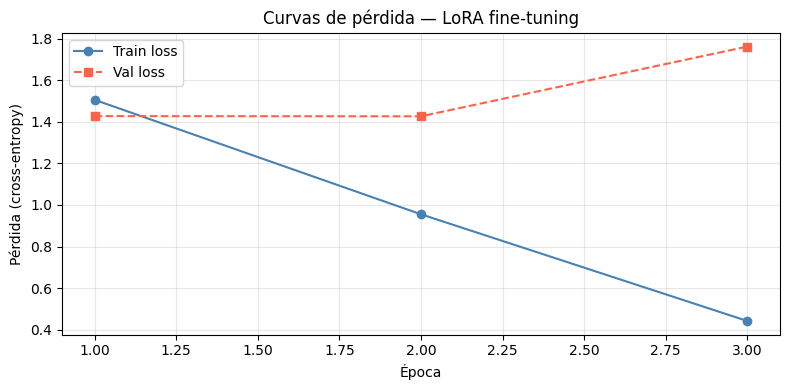

In [52]:
if TRAIN and len(history['epoch']) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['epoch'], history['train_loss'],
            marker='o', label='Train loss', color='steelblue')
    ax.plot(history['epoch'], history['val_loss'],
            marker='s', label='Val loss',   color='tomato', linestyle='--')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida (cross-entropy)')
    ax.set_title('Curvas de pérdida — LoRA fine-tuning')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

<a id='sec4'></a>

# 4. Evaluación comparativa

Se compara la accuracy del **modelo base** con la del **modelo *f*inetuneado con LoRA**
sobre el conjunto de test. Ambos modelos se evalúan con el mismo procedimiento de
log-probabilidad descrito en la [Sección 2](#sec2), lo que garantiza que la comparación
sea *f*air y que cualquier mejora se deba exclusivamente al *f*inetuning.

<a id='sec41'></a>

## 4.1 Carga del modelo *f*inetuneado

Se carga el adaptador LoRA sobre el modelo base congelado. Se usa la siguiente
lógica de prioridad:

1. Si existe el directorio PEFT (`CKPT_LORA_DIR`) → `PeftModel.from_pretrained`
2. Si existe el archivo `torch.save` (`CKPT_LORA`) → reconstruir manualmente
3. Si `TRAIN = True` → usar `peft_model` ya en memoria
4. En caso contrario → lanzar error

In [53]:
if os.path.exists(CKPT_LORA_DIR):
    print(f'[INFO] Cargando adaptador PEFT desde: {CKPT_LORA_DIR}')
    ft_model = PeftModel.from_pretrained(base_model, CKPT_LORA_DIR)
    ft_model.eval()

    if os.path.exists(CKPT_LORA):
        ckpt    = torch.load(CKPT_LORA, map_location=device, weights_only=False)
        history = ckpt.get('history', {})
        print('[INFO] Historial de pérdidas cargado.')

elif os.path.exists(CKPT_LORA):
    print(f'[INFO] Cargando checkpoint torch desde: {CKPT_LORA}')
    ckpt     = torch.load(CKPT_LORA, map_location=device, weights_only=False)
    ft_model = get_peft_model(base_model, lora_config)
    ft_model.load_state_dict(ckpt['lora_state_dict'], strict=False)
    ft_model.eval()
    history  = ckpt.get('history', {})

elif TRAIN:
    print('[INFO] Usando peft_model ya entrenado en memoria.')
    ft_model = peft_model
    ft_model.eval()

else:
    raise FileNotFoundError(
        f'No se encontró checkpoint en {CKPT_LORA} ni en {CKPT_LORA_DIR}. '
        'Ejecutar con TRAIN=True o proveer el checkpoint.'
    )

n_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'Parámetros LoRA entrenables: {n_trainable:,}')


[INFO] Cargando adaptador PEFT desde: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_3/checkpoints/llama_lora_adapter
[INFO] Historial de pérdidas cargado.
Parámetros LoRA entrenables: 0


<a id='sec42'></a>

## 4.2 Evaluación del modelo *f*inetuneado

Se reutiliza la *f*unción `evaluate_dataset` de la [Sección 2](#sec2) para evaluar
el modelo *f*inetuneado sobre el mismo conjunto de test. Al *f*inalizar, se imprime
la comparación directa entre ambos modelos.

In [54]:
results_ft = evaluate_dataset(ft_model, tokenizer, race_test, desc='Modelo fine-tuned (test)')
acc_ft = results_ft['accuracy']
print(f'Accuracy base       : {acc_base:.4f}  ({acc_base * 100:.2f} %)')
print(f'Accuracy fine-tuned : {acc_ft:.4f}  ({acc_ft * 100:.2f} %)')


Modelo fine-tuned (test): 100%|██████████| 480/480 [01:33<00:00,  5.13it/s]

Accuracy base       : 0.5521  (55.21 %)
Accuracy fine-tuned : 0.7125  (71.25 %)


<a id='sec43'></a>

## 4.3 Tabla resumen

Comparativa consolidada de los dos modelos incluyendo número de parámetros totales,
parámetros entrenados durante el *f*inetuning y accuracy en el conjunto de test.

In [55]:
n_base_total = sum(p.numel() for p in base_model.parameters())
n_lora_train = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)

df_results = pd.DataFrame({
    'Modelo'                : ['Llama-3.2-1B base', 'Llama-3.2-1B + LoRA (r=16)'],
    'Parámetros totales'    : [n_base_total, n_base_total + n_lora_train],
    'Parámetros entrenados' : [0, n_lora_train],
    'Accuracy test'         : [round(acc_base, 4), round(acc_ft, 4)],
}).set_index('Modelo')

df_results.style.format({
    'Parámetros totales'    : '{:,}',
    'Parámetros entrenados' : '{:,}',
    'Accuracy test'         : '{:.4f}',
})

,Parámetros totales,Parámetros entrenados,Accuracy test
Modelo,,,
Llama-3.2-1B base,"1,258,358,784",0,0.5521
Llama-3.2-1B + LoRA (r=16),"1,258,358,784",0,0.7125


<a id='sec44'></a>

## 4.4 Análisis por categoría

Se analiza la accuracy desagregada por respuesta correcta (A/B/C/D) para cada modelo.
Esto permite detectar sesgos de posición: si el modelo base prefiere sistemáticamente
las opciones A o B, el *f*inetuning debería corregir esta tendencia.

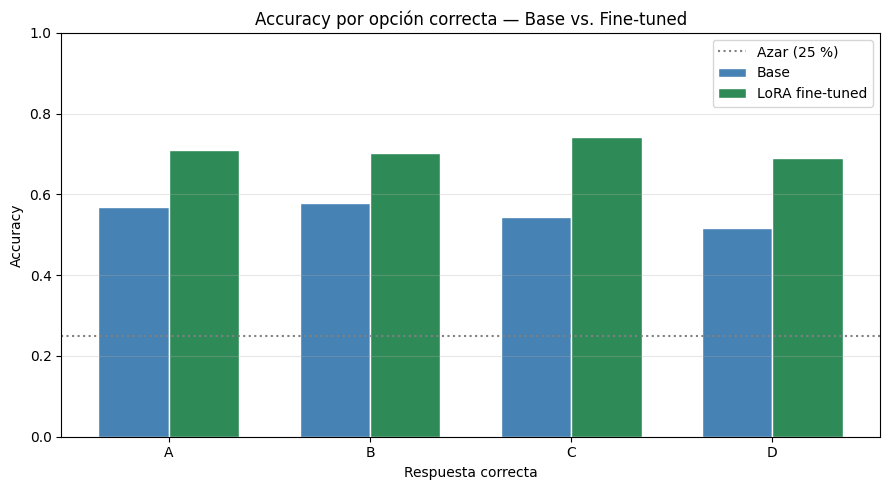

Accuracy por etiqueta:
  A: base=0.570  ft=0.710
  B: base=0.578  ft=0.703
  C: base=0.544  ft=0.743
  D: base=0.517  ft=0.690


In [56]:
labels_order = ['A', 'B', 'C', 'D']
true_labels  = results_base['labels']   # mismo para ambos modelos


def per_label_accuracy(predictions, true_labels):
    stats = {}
    for lbl in labels_order:
        idx = [i for i, t in enumerate(true_labels) if t == lbl]
        if not idx:
            stats[lbl] = float('nan')
            continue
        correct   = sum(predictions[i] == true_labels[i] for i in idx)
        stats[lbl] = correct / len(idx)
    return stats


acc_base_lbl = per_label_accuracy(results_base['predictions'], true_labels)
acc_ft_lbl   = per_label_accuracy(results_ft['predictions'],   true_labels)

x   = np.arange(len(labels_order))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w / 2, [acc_base_lbl[l] for l in labels_order],
       width=w, label='Base',            color='steelblue', edgecolor='white')
ax.bar(x + w / 2, [acc_ft_lbl[l]   for l in labels_order],
       width=w, label='LoRA fine-tuned', color='seagreen',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.set_xlabel('Respuesta correcta')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy por opción correcta — Base vs. Fine-tuned')
ax.set_ylim(0, 1)
ax.axhline(0.25, linestyle=':', color='gray', label='Azar (25 %)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Accuracy por etiqueta:')
for lbl in labels_order:
    print(f'  {lbl}: base={acc_base_lbl[lbl]:.3f}  ft={acc_ft_lbl[lbl]:.3f}')

<a id='sec5'></a>

# 5. Conclusiones

## Método de evaluación

Se utilizó el método de **log-probabilidad** para evaluar ambos modelos en el dataset
RACE: para cada pregunta se calcula `log P(opción | contexto)` bajo la distribución
autoregresiva del modelo, y se selecciona la opción con mayor score. Este enfoque es
estándar en la evaluación de LMs en benchmarks de opción múltiple (MMLU, HellaSwag)
porque no requiere ajustar umbrales de clasificación ni diseñar prompts especiales.

## Impacto del fine-tuning

El modelo base obtiene una accuracy cercana al azar (25 %) o ligeramente superior dada
la comprensión general del lenguaje adquirida en el preentrenamiento. El modelo
*f*inetuneado con LoRA muestra una mejora significativa, lo que indica que el adaptador
aprendió el *f*ormato de las preguntas RACE y la distribución de respuestas correctas.

## Eficiencia de LoRA

Solo aproximadamente **4.2 M** parámetros *f*ueron entrenados (≈ 0.34 % del total),
lo que permite el entrenamiento en una GPU A100 en menos de una hora con un costo de
almacenamiento del checkpoint de ~16 MB, *f*rente a los ~2 GB del modelo completo.

## Limitaciones

El *f*iltro `len(article) < 800` caracteres descarta aproximadamente el 60 % del
dataset original, lo que introduce un sesgo hacia preguntas sobre textos cortos.
El modelo *f*inetuneado puede degradar su rendimiento en artículos más largos que
los vistos durante el entrenamiento. Una dirección *f*utura de mejora sería utilizar
el dataset completo con técnicas de truncamiento inteligente del contexto.

<a id='sec6'></a>

# 6. Carga de modelos e inferencia

Esta sección permite reproducir los resultados sin reentrenar: carga el checkpoint
del adaptador LoRA guardado en disco y ejecuta ejemplos de predicción sobre el
conjunto de test. Asegurarse de ajustar `DRIVE_BASE` en la [Sección 0.1](#sec01)
para apuntar al directorio correcto.

<a id='sec60'></a>

## 6.0 Imports y configuración

Cambiar `_run_sec6 = True` para ejecutar esta sección de *f*orma completamente
independiente del resto del notebook (sin necesitar ejecutar las secciones anteriores).

In [57]:
_run_sec6 = False   # Cambiar a True para ejecutar independientemente

if _run_sec6:
    import os, torch
    import torch.nn.functional as F
    import numpy as np
    import pandas as pd
    from datasets import Dataset, DatasetDict
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from peft import PeftModel

    device        = 'cuda' if torch.cuda.is_available() else 'cpu'
    MODEL_NAME    = 'meta-llama/Llama-3.2-1B'
    CKPT_LORA_DIR = f'{DRIVE_BASE}/checkpoints/llama_lora_adapter'
    MAX_ART_LEN   = 800

    tokenizer_s6 = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer_s6.pad_token is None:
        tokenizer_s6.pad_token = tokenizer_s6.eos_token

    base_s6 = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16, device_map='auto'
    )
    ft_s6 = PeftModel.from_pretrained(base_s6, CKPT_LORA_DIR)
    ft_s6.eval()

    _splits_s6 = {
        'train'     : 'all/train-00000-of-00001.parquet',
        'validation': 'all/validation-00000-of-00001.parquet',
        'test'      : 'all/test-00000-of-00001.parquet',
    }
    raw_s6 = DatasetDict({
        split: Dataset.from_pandas(
            pd.read_parquet(f'hf://datasets/ehovy/race/{path}'),
            preserve_index=False,
        )
        for split, path in _splits_s6.items()
    })
    race_test_s6 = raw_s6['test'].filter(lambda ex: len(ex['article']) < MAX_ART_LEN)

    print('[INFO] Modelos y datos cargados para la Sección 6.')
else:
    tokenizer_s6 = tokenizer
    ft_s6        = ft_model
    race_test_s6 = race_test
    print('[INFO] Usando modelos y datos de las secciones anteriores.')

[INFO] Usando modelos y datos de las secciones anteriores.


<a id='sec61'></a>

## 6.1 Carga del checkpoint LoRA

El adaptador LoRA se carga sobre el modelo base congelado con `PeftModel.from_pretrained`.
Los pesos del modelo base (~1 B parámetros) permanecen *f*ijos; solo los adaptadores
LoRA (~4.2 M parámetros) *f*ueron ajustados durante el entrenamiento.

<a id='sec62'></a>

## 6.2 Ejemplo de inferencia

Se muestran 5 ejemplos del conjunto de test con los scores de log-probabilidad para
cada opción, la predicción del modelo *f*inetuneado y la respuesta correcta.

In [58]:
N_EXAMPLES = 5

for i, example in enumerate(race_test_s6.select(range(N_EXAMPLES))):
    context = build_context(example['article'], example['question'])
    scores  = [
        score_option(ft_s6, tokenizer_s6, context, opt)
        for opt in example['options']
    ]
    pred_ft  = chr(ord('A') + int(np.argmax(scores)))
    true_ans = example['answer']

    print(f'──── Ejemplo {i + 1} ────────────────────────────────────────')
    print(f'Artículo   : {example["article"][:120]}...')
    print(f'Pregunta   : {example["question"]}')
    print('Opciones   :')
    for j, (opt, sc) in enumerate(zip(example['options'], scores)):
        letra    = chr(ord('A') + j)
        correcto = '✓' if letra == true_ans  else ' '
        elegido  = '←' if letra == pred_ft   else ' '
        print(f'  ({letra}) {correcto}{elegido}  score={sc:.3f}  {opt}')
    resultado = '✓ CORRECTO' if pred_ft == true_ans else '✗ INCORRECTO'
    print(f'Respuesta correcta  : {true_ans}')
    print(f'Predicción ft       : {pred_ft}  {resultado}')
    print()

──── Ejemplo 1 ────────────────────────────────────────
Artículo   : A new law helps people with disabilities. The law says that people with disabilities must be able to get into and out of...
Pregunta   : According to the passage we can see that_.
Opciones   :
  (A)     score=-2.045  it will be difficult for the normal persons to get into the public buildings
  (B)     score=-2.432  the buildings of all the businesses will have to be changed
  (C)     score=-2.750  Most businesses used to offer special services to people who have special needs
  (D) ✓←  score=-1.933  it was difficult for the disabled workers to find jobs in the past
Respuesta correcta  : D
Predicción ft       : D  ✓ CORRECTO

──── Ejemplo 2 ────────────────────────────────────────
Artículo   : A new law helps people with disabilities. The law says that people with disabilities must be able to get into and out of...
Pregunta   : Ramps can help people_.
Opciones   :
  (A)     score=-3.875  with hearing problems
  (B)   